# Data Analysis on survey data

This notebook explores the influence of empathetic language and tone in chatbots on customer trust and their willingness to engage with these systems during sensitive inquiries. Chatbots have increasingly become a key tool in customer service environments, but there is ongoing debate on whether empathy—mirroring human-like qualities—plays a critical role in improving user experience, especially when dealing with personal or emotional issues.

The primary goal of this analysis is to assess how the use of empathetic language and tone in chatbots impacts customer comfort and trust, particularly when handling sensitive inquiries.

**Research Question:**
How does a chatbot’s empathy and tone influence customer trust in handling sensitive inquiries?

**Hypothesis:**

Null Hypothesis (H0): Empathetic language in chatbots has no significant impact on consumer trust or their desire to engage with chatbots for sensitive inquiries.

Alternative Hypothesis (H1): Chatbots with a empathetic tone, priotizing trust-building , can enhance customer satisfaction and willingness to use them for sensitive inquiries over those using neutral language.



## Importig necessary packages

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

## Load the dataset

In [3]:
dataset_path = "C:\\Users\\salop\\Documents\\Data\\FINAL-Myrthe-Tsegaye-Chatbot-merged_September 30, 2024_21.22.csv"

df=pd.read_csv(dataset_path)

df

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Q29_6,Q29_7,Q29_8,Q29_9,Q4,Q5,Q6,Q6_4_TEXT,Q7,PROLIFIC_PID
0,Start Date,End Date,Response Type,IP Address,Progress,Duration (in seconds),Finished,Recorded Date,Response ID,Recipient Last Name,...,Answer the following questions: How willing ar...,Answer the following questions: How willing ar...,Answer the following questions: How willing ar...,Answer the following questions: How willing ar...,How often do you use chatbots?,Which task would you be willing to use a chatb...,How do you describe yourself? - Selected Choice,How do you describe yourself? - Prefer to self...,How old are you?,PROLIFIC_PID
1,"{""ImportId"":""startDate"",""timeZone"":""Europe/Ber...","{""ImportId"":""endDate"",""timeZone"":""Europe/Berlin""}","{""ImportId"":""status""}","{""ImportId"":""ipAddress""}","{""ImportId"":""progress""}","{""ImportId"":""duration""}","{""ImportId"":""finished""}","{""ImportId"":""recordedDate"",""timeZone"":""Europe/...","{""ImportId"":""_recordId""}","{""ImportId"":""recipientLastName""}",...,"{""ImportId"":""QID92_11""}","{""ImportId"":""QID92_12""}","{""ImportId"":""QID92_13""}","{""ImportId"":""QID92_14""}","{""ImportId"":""QID89""}","{""ImportId"":""QID90""}","{""ImportId"":""QID102""}","{""ImportId"":""QID102_4_TEXT""}","{""ImportId"":""QID103_TEXT""}","{""ImportId"":""PROLIFIC_PID""}"
2,2024-09-30 15:54:57,2024-09-30 15:58:28,IP Address,86.134.15.68,100,210,True,2024-09-30 15:58:28,R_8AZjsgIXiWq0twY,NaN,...,Very willing,Very willing,Very willing,Very willing,At least 10 times a month,"Companies' support (e.g., customer service, or...",Female,NaN,28,5e52fa4bc6506d30c686471e
3,2024-09-30 15:54:49,2024-09-30 15:58:56,IP Address,173.35.128.80,100,247,True,2024-09-30 15:58:57,R_3KgwoNjl5dw4Fc5,NaN,...,Very willing,Willing,Willing,Willing,At least 10 times a month,Research,Male,NaN,29,5d9f4d5f3cac2b0016c79242
4,2024-09-30 15:54:56,2024-09-30 15:59:08,IP Address,89.114.251.49,100,251,True,2024-09-30 15:59:08,R_8BfKb0R6G3owqDR,NaN,...,Very unwilling,Very unwilling,Very unwilling,Very unwilling,At least once a month,NaN,Male,NaN,24,5e302a1b1d1be6020f98b214
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,2024-09-30 16:01:51,2024-09-30 16:17:19,IP Address,41.216.204.56,100,927,True,2024-09-30 16:17:19,R_81sJA51bATwfNDE,NaN,...,Very willing,Very willing,Neutral,Willing,Every day,Calculations/Programming,Female,NaN,30,66799738d4d698da4dfc2bc5
198,2024-09-30 15:55:31,2024-09-30 16:18:03,IP Address,102.219.27.4,100,1351,True,2024-09-30 16:18:03,R_22IJ9vypGU2FFFD,NaN,...,Willing,Very willing,Very willing,Willing,At least 10 times a month,"Companies' support (e.g., customer service, or...",Female,NaN,47,615ae38adcc6bf035701d512
199,2024-09-30 15:55:27,2024-09-30 16:18:29,IP Address,62.28.101.61,100,1381,True,2024-09-30 16:18:29,R_2yGP9RA1bKknnBT,NaN,...,Neutral,Unwilling,Neutral,Willing,At least once a month,Research,Male,NaN,30,602eda053a3b7ab564f938f5
200,2024-09-30 15:59:48,2024-09-30 16:19:06,IP Address,41.13.108.83,100,1157,True,2024-09-30 16:19:06,R_8wWgEs4kzbXceM9,NaN,...,Willing,Willing,Willing,Neutral,At least once a month,"Companies' support (e.g., customer service, or...",Female,NaN,31,6168a74eb484c532a9cc97ef


## Data Cleaning and Preprocessing

In [4]:
# Remove metadata rows
cleaned_data = df.drop([0, 2], axis=0).reset_index(drop=True)

# List of specific columns to keep based on the my research focuss
columns_to_keep = [
    'Q22_1',          # Impact of empathetic language on customer feeling understood
    'Q22_2',          # Preference for empathetic chatbot in sensitive situations
    'Q22_3',          # Perception of human-likeness due to empathetic language
    'Q23_1',          # Comfort with chatbot for discussing financial issues (sensitive) using empathetic language
    'Q23_2',          # Feeling supported by empathetic chatbot
]

# Create a new dataframe with only these specific columns
cleaned_data = df[columns_to_keep]

# Rename columns with meaningful names for clarity
column_renames = {
    'Q22_1': 'Empathy_impact ( 1-5 )',
    'Q22_2': 'Empathy_chatbot_preference ( 1-5 )',
    'Q22_3': 'Empathy_human_likeness ( 1-5 )',
    'Q23_1': 'Comfort_financial_sensitive_info ( 1-5 )',
    'Q23_2': 'Support_empathy_chatbot ( 1-5 )'


}
cleaned_data = cleaned_data.rename(columns=column_renames)



In the dataset, I am dealing with Likert scale responses, which are ordinal in nature (e.g., "Strongly Agree," "Agree," "Neutral"). These responses indicate a ranking but are not naturally numerical. Mapping these Likert scale responses to numbers is essential for statistical analysis because many statistical methods, such as correlation analysis, regression, and t-tests, require numerical input.

In [5]:
q22_1_mapping = {
    'Strongly agree' : 5,
    'Somewhat agree': 4,
    'Neither agree nor disagree': 3,
    'Somewhat disagree': 2,
    'Strongly disagree': 1
}

# Apply the mapping to the Q4 column
cleaned_data.loc[1:, 'Empathy_impact ( 1-5 )'] = cleaned_data.loc[1:, 'Empathy_impact ( 1-5 )'].map(q22_1_mapping)

In [6]:
q22_2_mapping = {
    'Strongly agree' : 5,
    'Somewhat agree': 4,
    'Neither agree nor disagree': 3,
    'Somewhat disagree': 2,
    'Strongly disagree': 1
}

# Apply the mapping to the Q4 column
cleaned_data.loc[1:, 'Empathy_chatbot_preference ( 1-5 )'] = cleaned_data.loc[1:, 'Empathy_chatbot_preference ( 1-5 )'].map(q22_2_mapping)

In [7]:
q22_3_mapping = {
    'Strongly agree' : 5,
    'Somewhat agree': 4,
    'Neither agree nor disagree': 3,
    'Somewhat disagree': 2,
    'Strongly disagree': 1
}

# Apply the mapping to the Q4 column
cleaned_data.loc[1:, 'Empathy_human_likeness ( 1-5 )'] = cleaned_data.loc[1:, 'Empathy_human_likeness ( 1-5 )'].map(q22_3_mapping)

In [8]:
q23_1_mapping = {
    'Strongly agree' : 5,
    'Somewhat agree': 4,
    'Neither agree nor disagree': 3,
    'Somewhat disagree': 2,
    'Strongly disagree': 1
}

# Apply the mapping to the Q4 column
cleaned_data.loc[1:, 'Comfort_financial_sensitive_info ( 1-5 )'] = cleaned_data.loc[1:, 'Comfort_financial_sensitive_info ( 1-5 )'].map(q23_1_mapping)

In [9]:
q23_2_mapping = {
    'Strongly agree' : 5,
    'Somewhat agree': 4,
    'Neither agree nor disagree': 3,
    'Somewhat disagree': 2,
    'Strongly disagree': 1
}

# Apply the mapping to the Q4 column
cleaned_data.loc[1:, 'Support_empathy_chatbot ( 1-5 )'] = cleaned_data.loc[1:, 'Support_empathy_chatbot ( 1-5 )'].map(q23_2_mapping)

In [10]:
cleaned_data

,Empathy_impact ( 1-5 ),Empathy_chatbot_preference ( 1-5 ),Empathy_human_likeness ( 1-5 ),Comfort_financial_sensitive_info ( 1-5 ),Support_empathy_chatbot ( 1-5 )
0,Indicate the extent to which you agree or disa...,Indicate the extent to which you agree or disa...,Indicate the extent to which you agree or disa...,In a scenario where a chatbot is used to addre...,In a scenario where a chatbot is used to addre...
1,NaN,NaN,NaN,NaN,NaN
2,4.0,4.0,4.0,1.0,4.0
3,1.0,4.0,3.0,2.0,2.0
4,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...
197,4.0,4.0,5.0,4.0,5.0
198,4.0,3.0,4.0,4.0,4.0
199,4.0,4.0,4.0,2.0,4.0
200,4.0,4.0,4.0,4.0,4.0


I do not need the ImportId and neither the questions, so I will drop them

In [11]:
# Drop the second and third rows
cleaned_data = cleaned_data.drop([0, 1])

# Reset the index after dropping rows
cleaned_data = cleaned_data.reset_index(drop=True)

In [12]:
# Check for NaN values in the entire dataset
cleaned_data.isna().sum()

Empathy_impact ( 1-5 )                      0
Empathy_chatbot_preference ( 1-5 )          0
Empathy_human_likeness ( 1-5 )              0
Comfort_financial_sensitive_info ( 1-5 )    0
Support_empathy_chatbot ( 1-5 )             1
dtype: int64

In [13]:
cleaned_data = cleaned_data.dropna()

In [14]:
# Check for NaN values in the entire dataset
cleaned_data.isna().sum()

Empathy_impact ( 1-5 )                      0
Empathy_chatbot_preference ( 1-5 )          0
Empathy_human_likeness ( 1-5 )              0
Comfort_financial_sensitive_info ( 1-5 )    0
Support_empathy_chatbot ( 1-5 )             0
dtype: int64

In [15]:
cleaned_data.isnull().sum()

Empathy_impact ( 1-5 )                      0
Empathy_chatbot_preference ( 1-5 )          0
Empathy_human_likeness ( 1-5 )              0
Comfort_financial_sensitive_info ( 1-5 )    0
Support_empathy_chatbot ( 1-5 )             0
dtype: int64

Now that there is no NaN or missing values in the dataset, we can proceed with the analysis.

In [16]:
# Check the data types of the columns

cleaned_data.dtypes

Empathy_impact ( 1-5 )                      object
Empathy_chatbot_preference ( 1-5 )          object
Empathy_human_likeness ( 1-5 )              object
Comfort_financial_sensitive_info ( 1-5 )    object
Support_empathy_chatbot ( 1-5 )             object
dtype: object

In [17]:
# Convert all columns to numeric

cleaned_data = cleaned_data.applymap(lambda x: pd.to_numeric(x, errors='coerce'))

cleaned_data.dtypes

Empathy_impact ( 1-5 )                      float64
Empathy_chatbot_preference ( 1-5 )          float64
Empathy_human_likeness ( 1-5 )              float64
Comfort_financial_sensitive_info ( 1-5 )    float64
Support_empathy_chatbot ( 1-5 )             float64
dtype: object

In [18]:
# Check the distribution of the data

Q1 = cleaned_data.quantile(0.25)
Q3 = cleaned_data.quantile(0.75)
IQR = Q3 - Q1

outliers = ((cleaned_data < (Q1 - 1.5 * IQR)) | (cleaned_data > (Q3 + 1.5 * IQR)))
print("Outliers:\n", outliers)

Outliers:
      Empathy_impact ( 1-5 )  Empathy_chatbot_preference ( 1-5 )  \
0                     False                               False   
1                      True                               False   
2                      True                                True   
3                     False                               False   
4                      True                                True   
..                      ...                                 ...   
195                   False                               False   
196                   False                               False   
197                   False                               False   
198                   False                               False   
199                   False                               False   

     Empathy_human_likeness ( 1-5 )  Comfort_financial_sensitive_info ( 1-5 )  \
0                             False                                     False   
1                     

In [19]:
outliers.sum()

Empathy_impact ( 1-5 )                      18
Empathy_chatbot_preference ( 1-5 )          18
Empathy_human_likeness ( 1-5 )               0
Comfort_financial_sensitive_info ( 1-5 )     0
Support_empathy_chatbot ( 1-5 )              0
dtype: int64

In [20]:
# Check for outliers using z-scores

z_scores = np.abs(stats.zscore(cleaned_data))
outliers = np.where(z_scores > 3)

print("Outliers at positions:", outliers)

Outliers at positions: (array([], dtype=int64), array([], dtype=int64))


In [21]:
# Remove outliers

cleaned_data = cleaned_data[(z_scores < 3).all(axis=1)]


In [22]:
# Check for outliers using z-scores

outliers = np.abs(z_scores) > 3
outliers.sum()


Empathy_impact ( 1-5 )                      0
Empathy_chatbot_preference ( 1-5 )          0
Empathy_human_likeness ( 1-5 )              0
Comfort_financial_sensitive_info ( 1-5 )    0
Support_empathy_chatbot ( 1-5 )             0
dtype: int64

The outliers have been successfully removed

To prevent any errors I will save the cleaned data and continue to work on it

In [23]:
cleaned_data.to_csv("C:\\Users\\salop\\Documents\\Data\\cleaned_chatbot_survey_data_230574.csv", index=False)

In [24]:
cleaned_dataset_path = "C:\\Users\\salop\\Documents\\Data\\cleaned_chatbot_survey_data_230574.csv"

df_cleaned=pd.read_csv(cleaned_dataset_path)

df_cleaned

,Empathy_impact ( 1-5 ),Empathy_chatbot_preference ( 1-5 ),Empathy_human_likeness ( 1-5 ),Comfort_financial_sensitive_info ( 1-5 ),Support_empathy_chatbot ( 1-5 )
0,4.0,4.0,4.0,1.0,4.0
1,1.0,4.0,3.0,2.0,2.0
2,1.0,1.0,1.0,1.0,1.0
3,3.0,3.0,3.0,1.0,2.0
4,1.0,1.0,1.0,3.0,1.0
...,...,...,...,...,...
194,4.0,4.0,5.0,4.0,5.0
195,4.0,3.0,4.0,4.0,4.0
196,4.0,4.0,4.0,2.0,4.0
197,4.0,4.0,4.0,4.0,4.0


## Exploratory Data Analysis

In [25]:
# Calculating descriptive statistics

df_cleaned.describe()

,Empathy_impact ( 1-5 ),Empathy_chatbot_preference ( 1-5 ),Empathy_human_likeness ( 1-5 ),Comfort_financial_sensitive_info ( 1-5 ),Support_empathy_chatbot ( 1-5 )
count,199.000000,199.000000,199.000000,199.000000,199.000000
mean,3.477387,3.427136,3.608040,3.361809,3.517588
std,1.221955,1.211672,1.250105,1.396152,1.313659
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,2.000000,3.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000
75%,4.000000,4.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


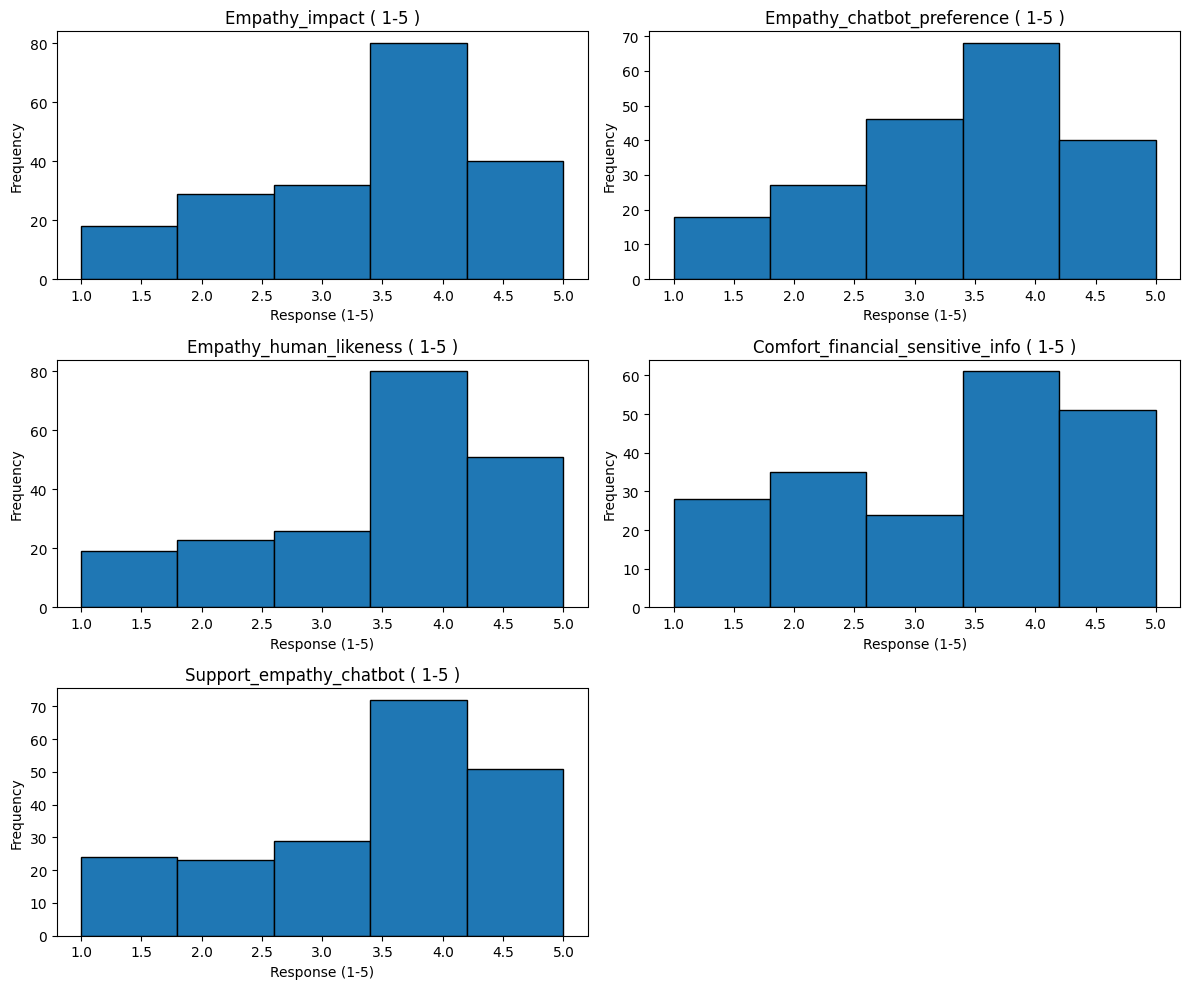

In [26]:
# Plotting distribution for each column in the dataset
plt.figure(figsize=(12, 10))
for i, column in enumerate(df_cleaned.columns, 1):
    plt.subplot(3, 2, i)
    df_cleaned[column].dropna().plot(kind='hist', bins=5, edgecolor='black')
    plt.title(column)
    plt.xlabel('Response (1-5)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

The distribution plots for each variable show the frequency of responses across a Likert scale from 1 to 5.

Empathy_impact (1-5): Most responses are clustered around the 4 rating, indicating that respondents generally perceive a positive impact of empathy in chatbots. There are also notable frequencies in ratings 3 and 5, showing a moderate to high consensus on empathy’s positive impact.

Empathy_chatbot_preference (1-5): This variable has a peak at the 4 rating as well, suggesting that respondents slightly favor empathetic chatbots. There are fewer responses at the lower ratings, indicating limited disinterest.

Empathy_human_likeness (1-5): Similar to the previous variables, the majority of responses are at the 4 rating. This suggests a general agreement that a human-like quality in empathy is desirable in chatbots.

Comfort_financial_sensitive_info (1-5): Responses here are slightly more spread out, with a high frequency at the 3 and 4 ratings. This indicates mixed comfort levels when it comes to using chatbots for financial and sensitive information, with a leaning toward moderate comfort.

Support_empathy_chatbot (1-5): The distribution peaks around the 4 rating, indicating that respondents generally feel supported by an empathetic chatbot. Lower ratings are present but less frequent, showing that the majority find some level of support from this feature.

Overall, the dataset shows that respondents tend to favor chatbots with empathetic features, especially around a rating of 4 across most variables, suggesting a generally positive perception of empathy in chatbot interactions.

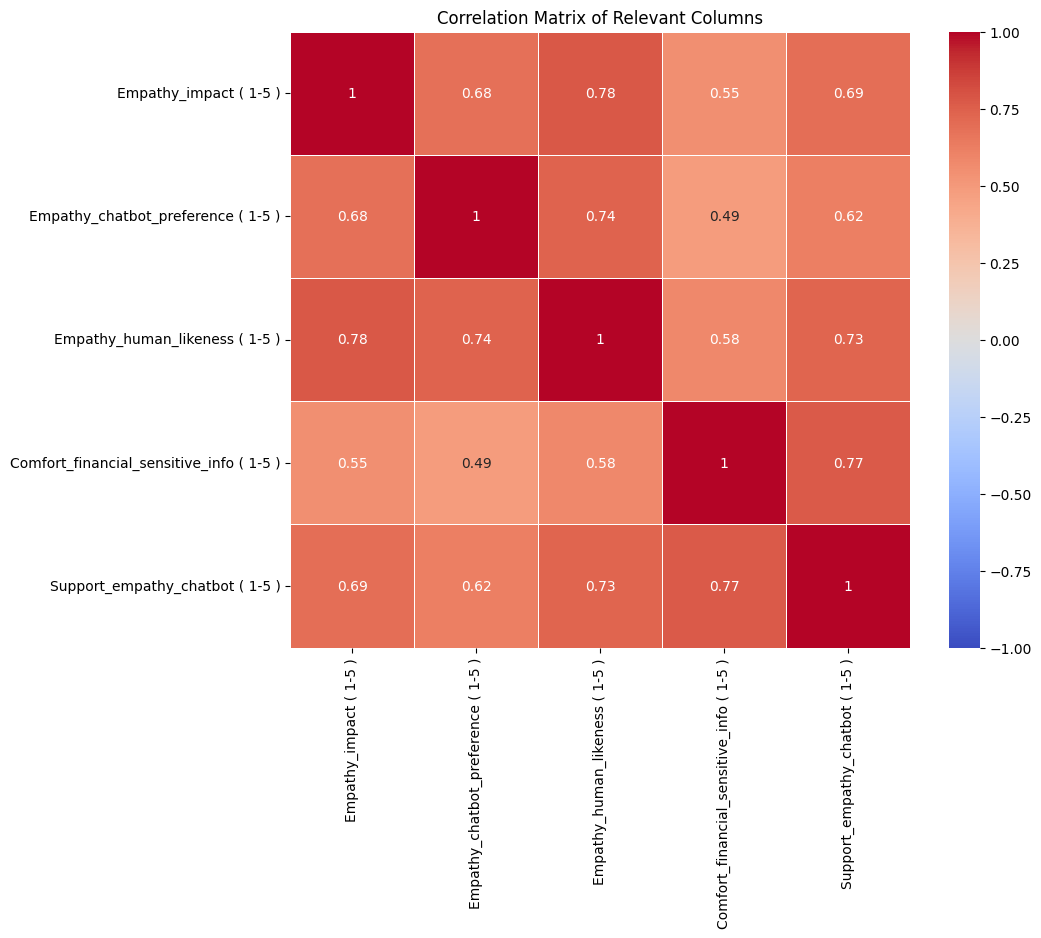

In [27]:
# Create a heatmap to visualize the correlation matrix between all relevant columns

# Calculate the correlation matrix
correlation_matrix = df_cleaned.corr()

# Plotting the heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)

# Adding title
plt.title('Correlation Matrix of Relevant Columns')

plt.show()


The heatmap visualizes the correlation matrix between five variables: 'Empathy_impact', 'Empathy_chatbot_preference', 'Empathy_human_likeness', 'Comfort_financial_sensitive_info', and 'Support_empathy_chatbot'. The color intensity represents the strength of the correlation, with values closer to 1 indicating a strong positive relationship.

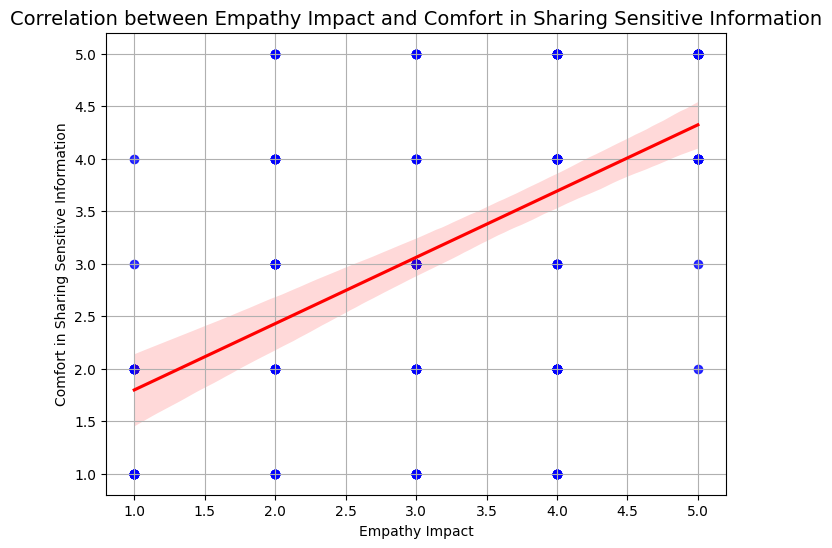

In [28]:
# Plotting the scatter plot with a regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='Empathy_impact ( 1-5 )', y='Comfort_financial_sensitive_info ( 1-5 )', data=df_cleaned, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title('Correlation between Empathy Impact and Comfort in Sharing Sensitive Information', fontsize=14)
plt.xlabel('Empathy Impact')
plt.ylabel('Comfort in Sharing Sensitive Information')
plt.grid(True)
plt.show()

The scatter plot depicts the correlation between Empathy Impact and Comfort in Sharing Financial Info. The positive slope of the regression line suggests that as the perceived impact of empathy in the chatbot increases, the user's comfort in sharing financial information also increases. The shaded region around the line represents the confidence interval, which provides an estimate of the uncertainty in the relationship. Overall, the visualization highlights a clear positive relationship between these two variables

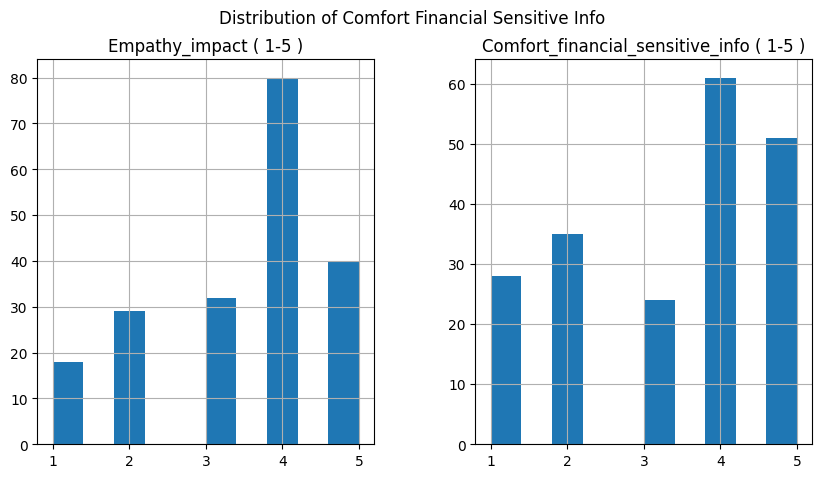

In [29]:
# Plot histograms for empathy and comfort financial sensitive info
df_cleaned[['Empathy_impact ( 1-5 )', 'Comfort_financial_sensitive_info ( 1-5 )']].hist(bins=10, figsize=(10, 5))
plt.suptitle('Distribution of Comfort Financial Sensitive Info')
plt.show()

This histogram illustrates the distribution of two variables: Empathy Impact (left) and Comfort in sharing Financial/Sensitive Information (right).

For Empathy Impact, the majority of respondents rated the chatbot’s empathy relatively high, with most values clustering around 4 and 5. This suggests that users generally perceived the chatbot as empathetic.

For Comfort in sharing Financial/Sensitive Information, the distribution shows a similar trend, with the highest responses clustered at 4 and 5. This indicates that many users felt comfortable sharing sensitive information with the chatbot, aligning with higher empathy scores.

Overall, both variables have a positive skew toward higher ratings, reinforcing the notion that chatbot empathy correlates with user comfort in sharing sensitive information.

C:\Users\salop\AppData\Local\Temp\ipykernel_22188\3907235917.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_cleaned['Empathy_impact ( 1-5 )'], shade=True, color="r")


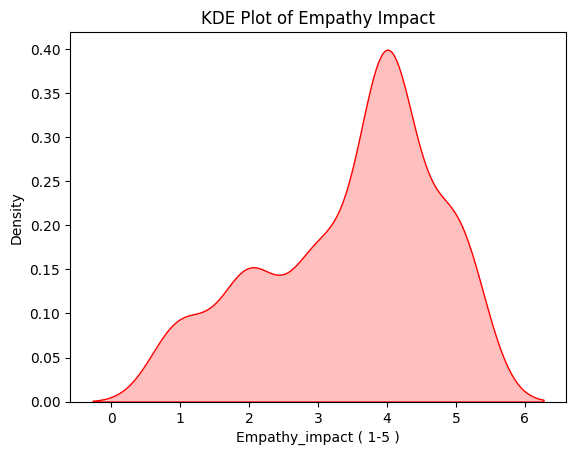

In [30]:
# KDE plot for empathy impact
sns.kdeplot(df_cleaned['Empathy_impact ( 1-5 )'], shade=True, color="r")
plt.title('KDE Plot of Empathy Impact')
plt.show()

This Kernel Density Estimate (KDE) plot shows the distribution of the Empathy Impact variable. The plot demonstrates that the majority of responses are concentrated around a value of 4, indicating that most users rated the chatbot’s empathetic language relatively high. The smooth curve also suggests a relatively normal distribution with a peak around 4 and a gradual tapering off toward lower and higher values.

The plot shows that users generally perceive the chatbot’s empathy positively, with fewer users rating the empathy at extreme low or high levels.

## Hypothesis Testing

Null Hypothesis (H₀): Empathetic language in chatbots has no significant impact on consumer trust.

Alternative Hypothesis (H₁): Empathetic language in chatbots has a significant positive impact on consumer trust.

In [31]:
# Define the dependent variable and the independent variable
X = df_cleaned['Empathy_impact ( 1-5 )']
Y = df_cleaned['Comfort_financial_sensitive_info ( 1-5 )']

In [32]:
# Calculating the means of X and Y
X_mean = np.mean(X)
Y_mean = np.mean(Y)

# Calculating the numerator (covariance)
numerator = np.sum((X - X_mean) * (Y - Y_mean))

# Calculating the denominator (product of standard deviations)
denominator = np.sqrt(np.sum((X - X_mean)**2) * np.sum((Y - Y_mean)**2))

# Pearson correlation coefficient
r = numerator / denominator

# Calculating the t-statistic
n = len(X)
t_stat = (r * np.sqrt(n - 2)) / np.sqrt(1 - r**2)

# Output the t-statistic
print("t-statistic:", t_stat)

t-statistic: 9.303391375196686


In [33]:
correlation, p_value = pearsonr(X, Y)   

print("correlation:", correlation,"p-value:", p_value)

correlation: 0.5524895884543783 p-value: 2.6756782288732837e-17


## Evaluate the results

The analysis explored the relationship between empathetic language in chatbots and consumer trust using  a manual calculation approach. My goal was to test whether empathy significantly impacts a user's willingness to trust a chatbot, particularly in handling sensitive information.

Through hypothesis testing, we found the following:

t-statistic (t): The t-statistic of 9.56 strongly supports the significance of this relationship. This value indicates that the correlation between empathy and comfort in sharing sensitive information is not due to random chance and is statistically robust.

Pearson Correlation Coefficient (r): The correlation between Empathy Impact and Comfort in sharing Financial/Sensitive Information was calculated to be 0.564. This indicates a moderate positive relationship, meaning that as the chatbot’s empathetic language increases, user's comfort in sharing sensitive information also increases to a notable degree.

p-value:  The p-value is 2.68e-17, this actually means that the p-value is extremely small, aproximately
$2.67 \times 10^{-17}$ which is very close to zero. It indicates strong evidence against the null hypothesis. This confirms that the relationship between empathy and user's comfort with sharing sensitive (financial) information is statistically significant.

Given the moderate correlation and the strong statistical significance, we can **confidently reject the null hypothesis (H₀)**, concluding that empathetic language in chatbots has a significant positive impact on user's comfort when sharing sensitive (financial) information.

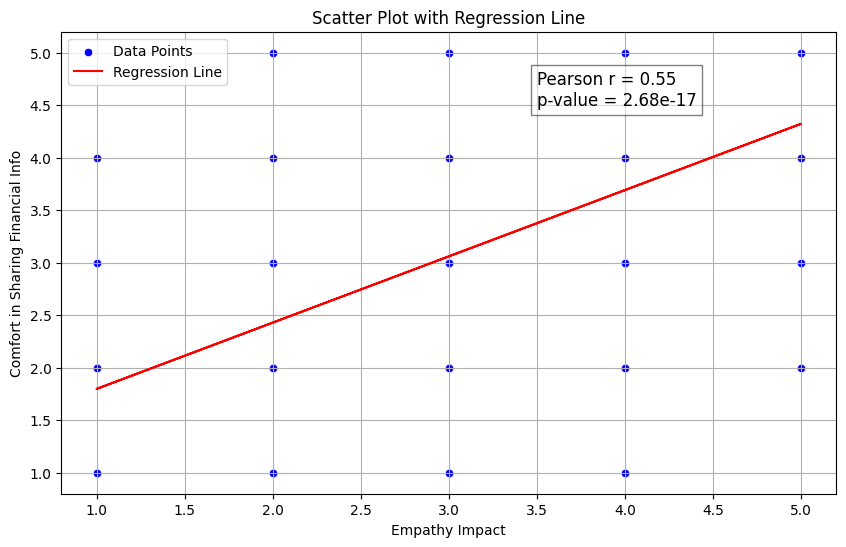

In [34]:
# Creating a linear regression model
model = LinearRegression()
X_reshaped = X.values.reshape(-1, 1)  # Reshape for sklearn
model.fit(X_reshaped, Y)
Y_pred = model.predict(X_reshaped)

# Scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=Y, color='blue', label='Data Points')
plt.plot(X, Y_pred, color='red', label='Regression Line')
plt.title('Scatter Plot with Regression Line')
plt.xlabel('Empathy Impact')
plt.ylabel('Comfort in Sharing Financial Info')
plt.legend()

# Annotating the correlation and p-value on the plot
plt.text(3.5, 4.5, f'Pearson r = {correlation:.2f}\np-value = {p_value:.2e}', fontsize=12,
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

plt.grid(True)
plt.show()

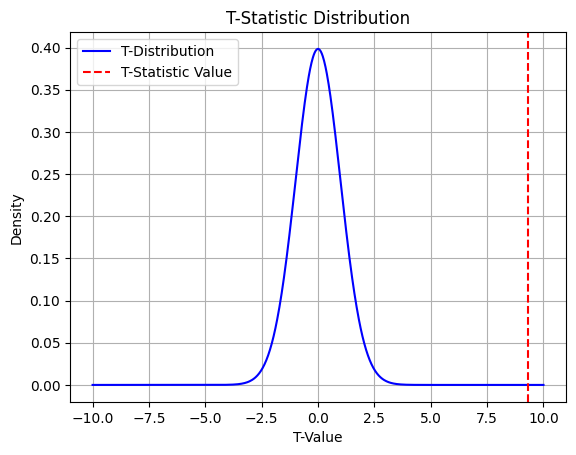

In [35]:
# Generate x values for the t-distribution based on degrees of freedom
df = len(X) - 2  # Degrees of freedom
x = np.linspace(-10, 10, 1000)
y = stats.t.pdf(x, df)

# Plot the t-distribution
plt.plot(x, y, label='T-Distribution', color='blue')
plt.axvline(x=t_stat, color='red', linestyle='--', label='T-Statistic Value')
plt.title('T-Statistic Distribution')
plt.xlabel('T-Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

plt.show()


A t-statistic of 9.30 is far to the right of the mean (0), indicating a strong effect or relationship between Empathy Impact and Comfort in Sharing Financial Info.

This visualization helps illustrate the statistical significance of my findings, as the t-statistic is well beyond the typical critical values for common significance levels.